In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Screen for autofluorescence

**Question**: can we screen for colors based on autofluorescence signal ?

**Method**: using excitation/emission data from the 23 strains collection

## Set background and OD600 

In [ ]:
dfwhite = pd.read_excel("/Users/astr/Documents/Pigments/PlateReaderData/251104_R_SpectralScanning.xlsx", sheet_name=0)
wl = dfwhite['Wavelength']
data = dfwhite.drop(columns=['Wavelength']) #keep only data

#OD600 
idx_600 = wl[wl == 600].index[0]
raw_600 = data.loc[idx_600]
background_600 = raw_600[['C12', 'D12']]
mean_background_600 = background_600.mean()
corrected_600 = raw_600 - mean_background_600 # X-values for scatter plots

# define colored wells
colored = ['A12', 'B12', 'C1', 'D1', 'C2', 'D2', 'C4', 'D4', 'C6', 'D6', 'C7', 'D7', 'A8', 'B8']


## Autofluorescence - Excitation @ 479nm

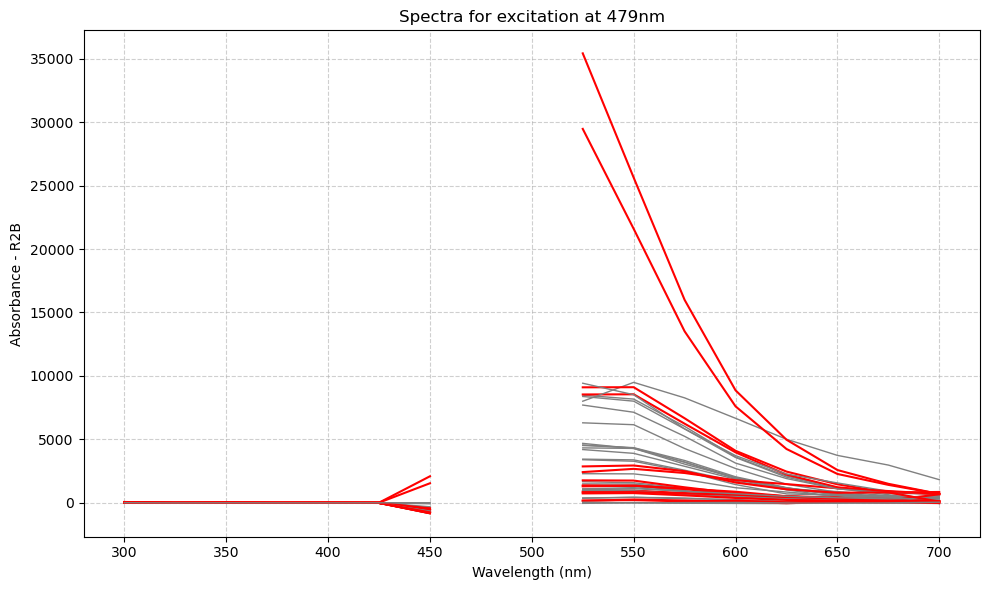

In [ ]:
df479 = pd.read_excel("/Users/astr/Documents/Pigments/PlateReaderData/251104_R_SpectralScanning.xlsx", sheet_name=1)


wl = df479['Wavelength']
data = df479.drop(columns=['Wavelength']) #keep only data
colored = ['A12', 'B12', 'C1', 'D1', 'C2', 'D2', 'C4', 'D4', 'C6', 'D6', 'C7', 'D7', 'A8', 'B8']

# Remove R2B background
background = data[['C12','D12']]
background_mean = background.mean(axis=1)
data_corrected = data.sub(background_mean, axis=0)

# Plot all spectra
plt.figure(figsize=(10, 6))

for column in data_corrected.columns:
    # Check if the current sample is in our list
    if column in colored:
        color = 'red'
        linewidth = 1.5  # Optional: make them slightly thicker to stand out
    else:
        color = 'grey'
        linewidth = 1.0
    
    plt.plot(wl, data_corrected[column], label=column if column in colored else "", 
             color=color, linewidth=linewidth)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Emission - R2B')
plt.title('Emission spectra for excitation @ 479nm')
#plt.legend(title='Samples', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()






At 550nm, the influence of excitation light is low and strains show different absorbances. 
We can plot the absorbance at 550 versus absorbane at 600nm.

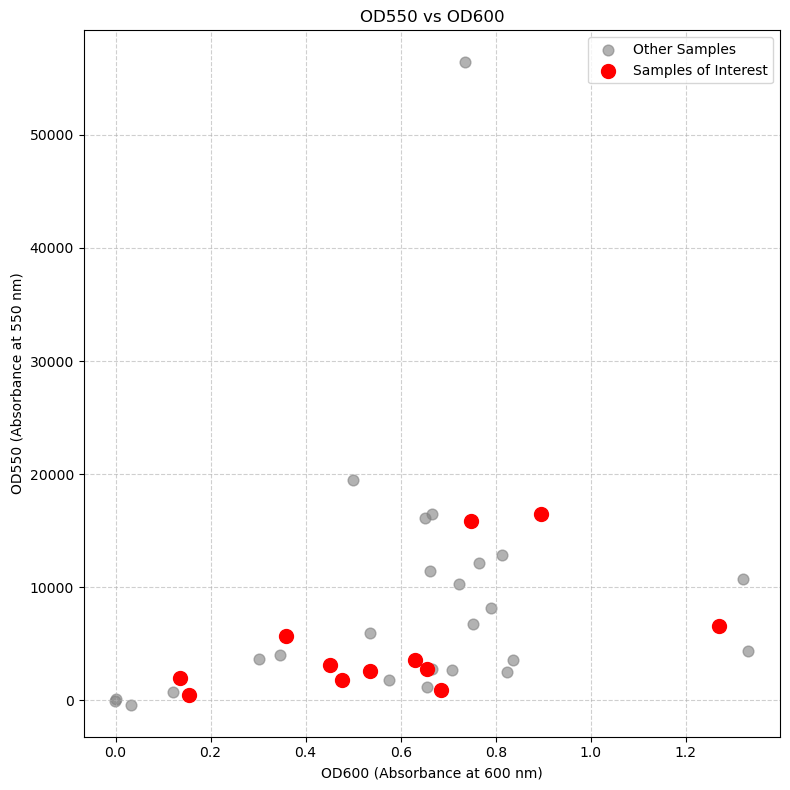

In [ ]:
from matplotlib.lines import Line2D


# Find the row indices for 550nm and 600nm
# This finds the index in the 'wl' series where the value equals 550 or 600
# We use [0] because the result is a series, and we want the single integer index
idx_550 = wl[wl == 550].index[0]

# 3. Extract the absorbance values at these specific wavelengths for all samples
abs_550 = data_corrected.loc[idx_550]

# 4. Create the scatter plot
plt.figure(figsize=(8, 8))

# Separate samples
red_samples = [col for col in data_corrected.columns if col in colored]
other_samples = [col for col in data_corrected.columns if col not in colored]

# Plot Other Samples (Grey) - X=600, Y=550
plt.scatter(corrected_600[other_samples], abs_550[other_samples], 
            color='grey', s=60, alpha=0.6, label='Other Samples')

# Plot Samples of Interest (Red) - X=600, Y=550
# Plotted second so they appear on top
plt.scatter(corrected_600[red_samples], abs_550[red_samples], 
            color='red', s=100, zorder=5, label='Samples of Interest')

# 5. Labels and Legend
plt.xlabel('OD600 (Absorbance at 600 nm)')  # X-axis
plt.ylabel('Emission @ 550 nm)')  # Y-axis
plt.title('Excitation @ 479nm')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Autofluorescence - Excitation @ 435nm

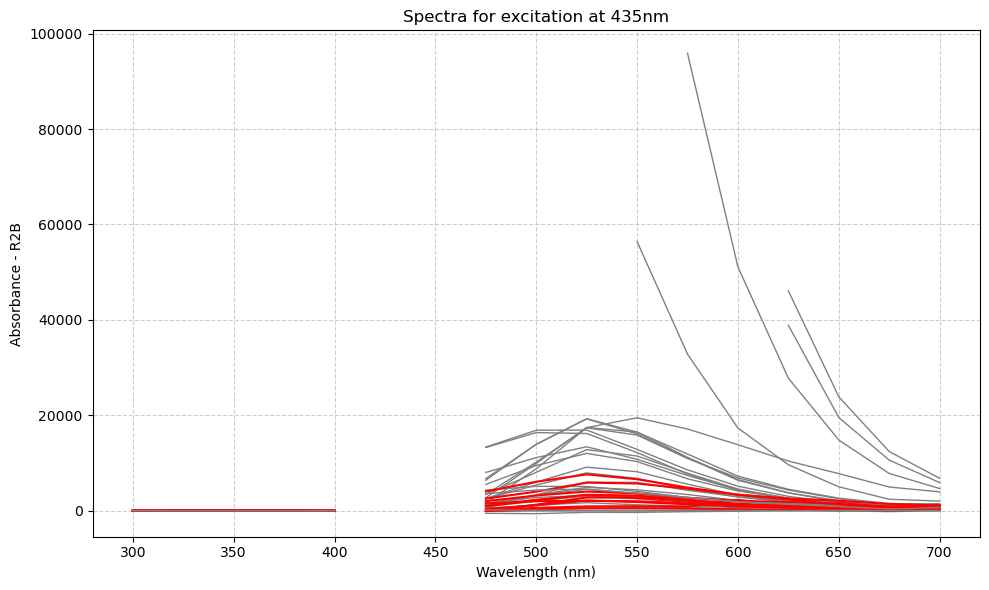

In [ ]:
df435 = pd.read_excel("/Users/astr/Documents/Pigments/PlateReaderData/251104_R_SpectralScanning.xlsx", sheet_name=2)
wl = df435['Wavelength']
data = df435.drop(columns=['Wavelength']) #keep only data
colored = ['A12', 'B12', 'C1', 'D1', 'C2', 'D2', 'C4', 'D4', 'C6', 'D6']

# Remove R2B background
background = data[['C12','D12']]
background_mean = background.mean(axis=1)
data_corrected = data.sub(background_mean, axis=0)

# Plot all spectra
plt.figure(figsize=(10, 6))

for column in data_corrected.columns:
    # Check if the current sample is in our list
    if column in colored:
        color = 'red'
        linewidth = 1.5  # Optional: make them slightly thicker to stand out
    else:
        color = 'grey'
        linewidth = 1.0
    
    plt.plot(wl, data_corrected[column], label=column if column in colored else "", 
             color=color, linewidth=linewidth)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Emission - R2B')
plt.title('Emission spectra for excitation at 435nm')
#plt.legend(title='Samples', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


With excitation at 435nm, it is also not obvious to separate colored from not colored samples. Let's see with scatter plot of OD600 vs OD525.

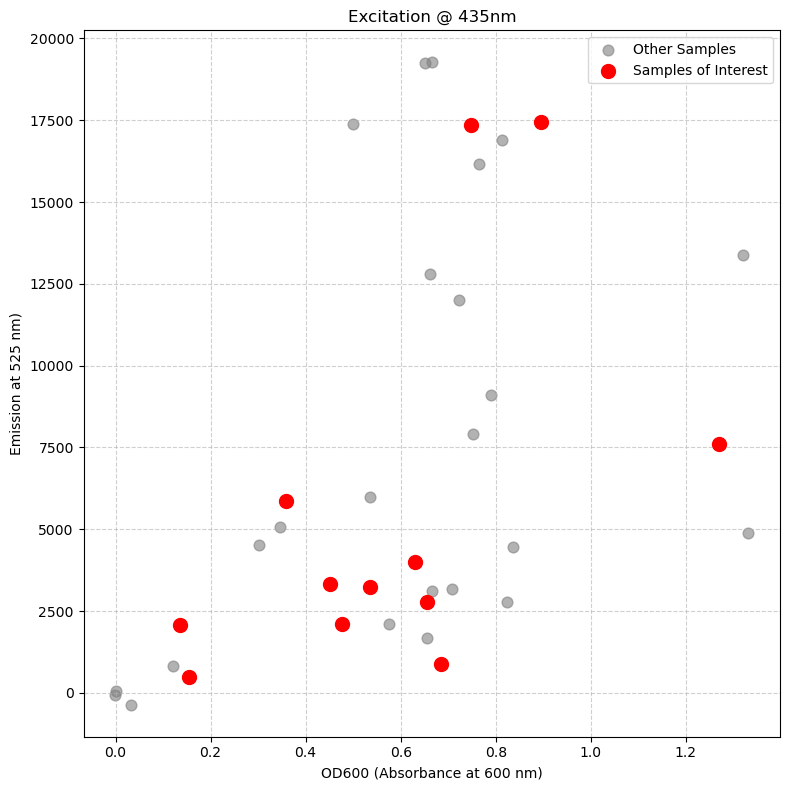

In [32]:


# Find the row indices for 525nm and 600nm
# This finds the index in the 'wl' series where the value equals 550 or 600
# We use [0] because the result is a series, and we want the single integer index
idx_525 = wl[wl == 525].index[0]

# 3. Extract the absorbance values at these specific wavelengths for all samples
abs_525 = data_corrected.loc[idx_525]

# 4. Create the scatter plot
plt.figure(figsize=(8, 8))

# Separate samples
red_samples = [col for col in data_corrected.columns if col in colored]
other_samples = [col for col in data_corrected.columns if col not in colored]

# Plot Other Samples (Grey) - X=600, Y=550
plt.scatter(corrected_600[other_samples], abs_525[other_samples], 
            color='grey', s=60, alpha=0.6, label='Other Samples')

# Plot Samples of Interest (Red) - X=600, Y=550
# Plotted second so they appear on top
plt.scatter(corrected_600[red_samples], abs_525[red_samples], 
            color='red', s=100, zorder=5, label='Samples of Interest')

# 5. Labels and Legend
plt.xlabel('OD600 (Absorbance at 600 nm)')  # X-axis
plt.ylabel('Emission at 525 nm)')  # Y-axis
plt.title('Excitation @ 435nm')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Autofluorescence - Excitation @ 579nm

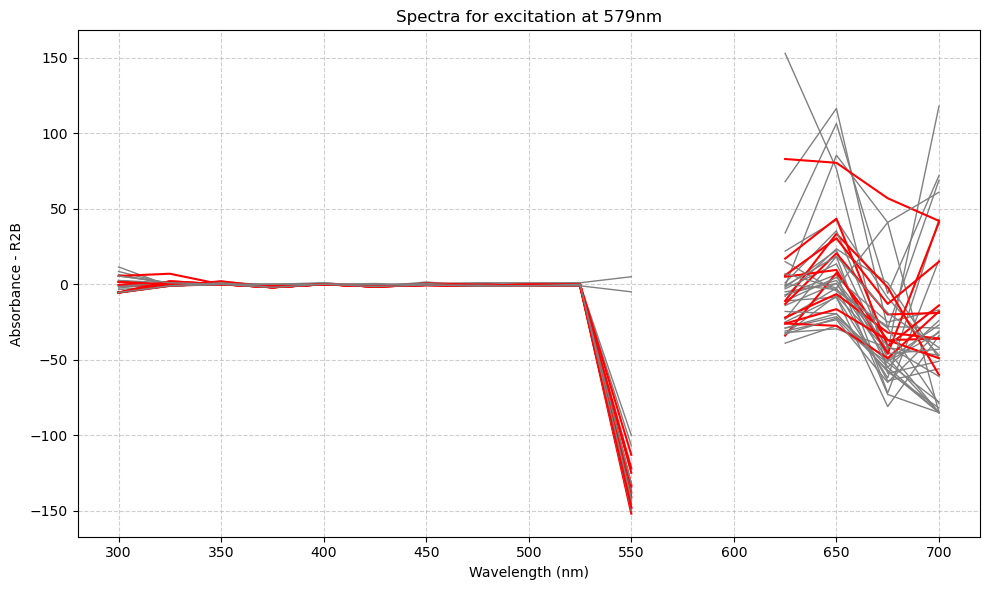

In [ ]:
df579 = pd.read_excel("/Users/astr/Documents/Pigments/PlateReaderData/251104_R_SpectralScanning.xlsx", sheet_name=3)
wl = df579['Wavelength']
data = df579.drop(columns=['Wavelength']) #keep only data
colored = ['A12', 'B12', 'C1', 'D1', 'C2', 'D2', 'C4', 'D4', 'C6', 'D6']

# Remove R2B background
background = data[['C12','D12']]
background_mean = background.mean(axis=1)
data_corrected = data.sub(background_mean, axis=0)

# Plot all spectra
plt.figure(figsize=(10, 6))

for column in data_corrected.columns:
    # Check if the current sample is in our list
    if column in colored:
        color = 'red'
        linewidth = 1.5  # Optional: make them slightly thicker to stand out
    else:
        color = 'grey'
        linewidth = 1.0
    
    plt.plot(wl, data_corrected[column], label=column if column in colored else "", 
             color=color, linewidth=linewidth)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Excitation - R2B')
plt.title('Emission spectra for excitation at 579nm')
#plt.legend(title='Samples', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


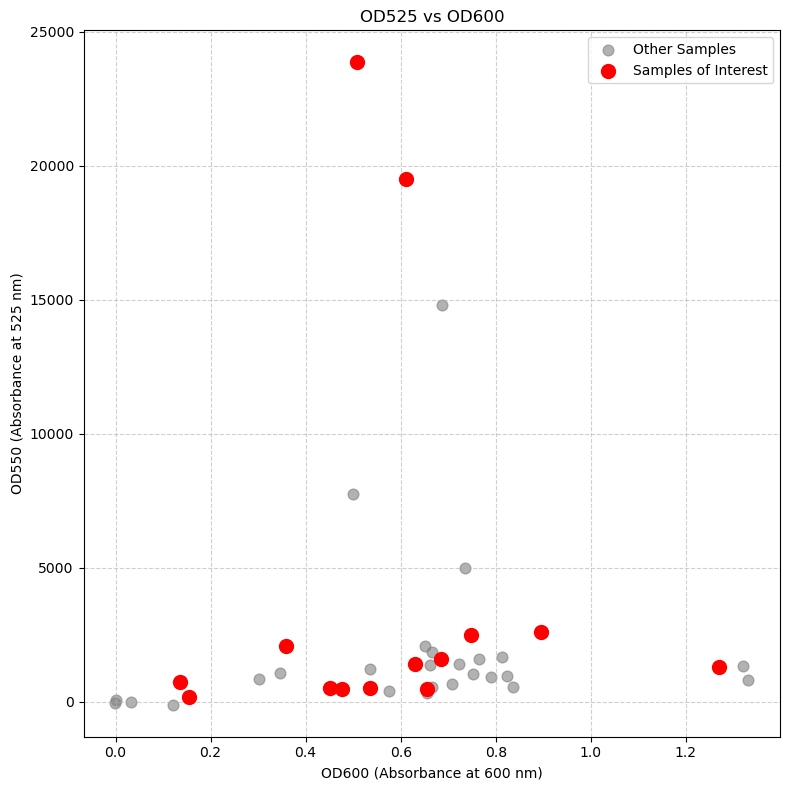

In [ ]:


# Find the row indices for 525nm and 600nm
# This finds the index in the 'wl' series where the value equals 550 or 600
# We use [0] because the result is a series, and we want the single integer index

emission = 650
idx = wl[wl == emission].index[0]

# 3. Extract the absorbance values at these specific wavelengths for all samples
abs = data_corrected.loc[idx]

# 4. Create the scatter plot
plt.figure(figsize=(8, 8))

# Separate samples
red_samples = [col for col in data_corrected.columns if col in colored]
other_samples = [col for col in data_corrected.columns if col not in colored]

# Plot Other Samples (Grey) - X=600, Y=550
plt.scatter(corrected_600[other_samples], abs[other_samples], 
            color='grey', s=60, alpha=0.6, label='Other Samples')

# Plot Samples of Interest (Red) - X=600, Y=550
# Plotted second so they appear on top
plt.scatter(corrected_600[red_samples], abs[red_samples], 
            color='red', s=100, zorder=5, label='Samples of Interest')

# 5. Labels and Legend
plt.xlabel('OD600 (Absorbance at 600 nm)')  # X-axis
plt.ylabel('Emission @ 650 nm)')  # Y-axis
plt.title('Excitation @ 579')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

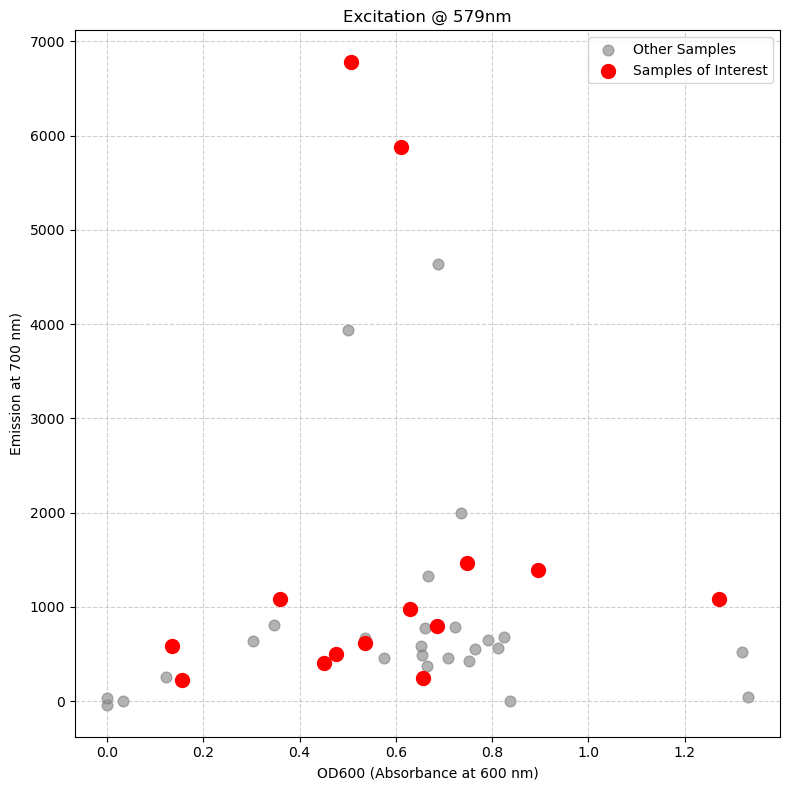

In [31]:


# Find the row indices for 525nm and 600nm
# This finds the index in the 'wl' series where the value equals 550 or 600
# We use [0] because the result is a series, and we want the single integer index

emission = 700
idx = wl[wl == emission].index[0]

# 3. Extract the absorbance values at these specific wavelengths for all samples
abs = data_corrected.loc[idx]

# 4. Create the scatter plot
plt.figure(figsize=(8, 8))

# Separate samples
red_samples = [col for col in data_corrected.columns if col in colored]
other_samples = [col for col in data_corrected.columns if col not in colored]

# Plot Other Samples (Grey) - X=600, Y=550
plt.scatter(corrected_600[other_samples], abs[other_samples], 
            color='grey', s=60, alpha=0.6, label='Other Samples')

# Plot Samples of Interest (Red) - X=600, Y=550
# Plotted second so they appear on top
plt.scatter(corrected_600[red_samples], abs[red_samples], 
            color='red', s=100, zorder=5, label='Samples of Interest')

# 5. Labels and Legend
plt.xlabel('OD600 (Absorbance at 600 nm)')  # X-axis
plt.ylabel('Emission at 700 nm)')  # Y-axis
plt.title('Excitation @ 579nm')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()